# Lab 2 Ghofran's code

In [ ]:
#####################################
### Import the relevant libraries ###
#####################################
import random # to set a random seed for reproducibility (ensures consistent random splits or shuffling)
import numpy as np # handles numerical operations, arrays, and matrix manipulations
import pandas as pd # for data handling and analysis (loading, cleaning, and transforming tabular data)
import matplotlib.pyplot as plt # for creating visualizations (accuracy/loss curves, confusion matrix, etc.)

from sklearn.model_selection import train_test_split # to split the dataset into training and testing sets
# Converts text into numerical representations based on importance of words
# (TF-IDF = Term Frequency–Inverse Document Frequency)
from sklearn.feature_extraction.text import TfidfVectorizer
# Scales all numerical values to a range [0,1]
# This helps the neural network converge faster and allows PGD attacks to stay within defined bounds
from sklearn.preprocessing import MinMaxScaler
# Provides common metrics to evaluate model performance:
#  - classification_report: precision, recall, F1-score summary
#  - confusion_matrix: compares predicted vs actual labels
#  - accuracy_score: overall accuracy
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Handles class imbalance by assigning weights to each class during training
# so that minority classes have a stronger influence on the loss
from sklearn.utils.class_weight import compute_class_weight
# to reduce high-dimensional TF-IDF vectors to 2D or 3D for visualization
from sklearn.decomposition import PCA
# t-SNE (t-distributed Stochastic Neighbor Embedding): another method for visualizing high-dimensional data
from sklearn.manifold import TSNE
# Standardizes data (zero mean, unit variance): sometimes useful before applying dimensionality reduction
from sklearn.preprocessing import StandardScaler
# UMAP (Uniform Manifold Approximation and Projection): another method for visualizing embeddings
import umap


# TensorFlow and Keras: import, build, and train the neural networks
import tensorflow as tf # the main library for training and running deep neural networks
from tensorflow import keras # Keras: high-level API for building and training models
# layers: building blocks of the neural network (e.g., Dense, Dropout, Input)
# Model: allows defining models that output intermediate layers (used later for feature visualization)
from tensorflow.keras import layers, Model


In [ ]:
########################
##### Define Seeds #####
########################
# Setting a fixed seed ensures that any random operation (e.g., random shuffling of data,
# random weight initialization in the model, or random sampling in train/test splits)
# produces the same result every time we run the notebook. This makes the experiments reproducible.
SEED = 42 # any integer works, 42 a common default used in research examples
# --- Apply the seed to all relevant libraries ---
np.random.seed(SEED) # affects anything that uses np.random (e.g., shuffling arrays, splitting data manually).
tf.random.set_seed(SEED) # ensures neural network initialization, dropout layers, and training shuffles are consistent.
random.seed(SEED) # sets the seed for Python’s built-in random library

In [ ]:
####################################
########### Load datasets ##########
####################################
# paths to both datasets
EXPERT_PATH = "cleaned_medicheck-expert.csv"    # The labelled expert dataset (contains 'query' and 'query-label-expert')
NEG_PATH    = "medicheck-neg.csv"               # The unlabelled negative dataset (contains non-medical queries)

# Load the expert (medical) dataset
# Notes:
# - The expert dataset contains both medical and a few non-medical queries.
# - It includes a column called 'query-label-expert' with numeric labels 0, 1, 2, 3
#   where (0 = non-medical, 1–3 = varying levels of medical seriousness).
expert_df = pd.read_csv(EXPERT_PATH) # Reads the CSV file into a pandas DataFrame
print("Expert dataset:", expert_df.shape) # Prints dataset dimensions: (number of rows, number of columns)
print(expert_df.head(3)) # show the first 3 rows of the dataset

# Load the negative (non-medical) dataset
# Notes:
# - This dataset has only one column: 'query'
# - It includes extra non-medical examples to balance the dataset
# - It doesn’t come with labels, so we’ll assign label = 1 (non-medical) manually later
neg_df = pd.read_csv(NEG_PATH) # Reads the CSV file with all negative (non-medical) queries
print("Negative dataset:", neg_df.shape)  # Prints shape (rows, columns)
print(neg_df.head(3)) # show the first 3 rows of the dataset

Expert dataset: (1416, 2)
                                               query  query-label-expert
0  Why do i get a bad headache when i don't eat e...                   2
1  What causes heart rate to suddenly quicken to ...                   2
2  peritonsillar abscess drainage aftercare.. ple...                   2
Negative dataset: (1499, 1)
                                               query
0  If ingesting salt causes dehydration and dehyd...
1      What's the worst thing you did as a teenager?
2                       What is your biggest regret?


In [ ]:
##############################################
### Relabel to binary according to ANTONIO ###
##############################################
# Define Antonio's relabelling rule
def antonio_relabel(x):
      """
    Converts the original 'query-label-expert' numeric codes
    into a binary format following Antonio's comprehension:

    Original labels meaning (from expert dataset):
        0: non-medical query
        1: mild medical
        2: serious medical
        3: very serious medical

    Antonio's rule:
        - All medical queries (1, 2, 3) become label 0 = "medical"
        - All non-medical queries (0) become label 1 = "non-medical"
        - Anything unexpected becomes NaN (missing)
    """
    if x in [1, 2, 3]:   # any medical seriousness level
        return 0         # medical (positive class for Antonio)
    elif x == 0:         # not a medical query
        return 1         # non-medical (negative class for Antonio)
    else:
        return np.nan    # mark any undefined label as missing for later removal

# Apply the relabeling function and clean the dataframe
# Keep only the two columns we care about:
#  - "query": text of the question
#  - "query-label-expert": numeric label assigned
expert_df = expert_df[["query", "query-label-expert"]].copy()
# Apply the Antonio relabel function to each label value
# to create a new column called "label" with 0s (medical) and 1s (non-medical)
expert_df["label"] = expert_df["query-label-expert"].apply(antonio_relabel)
# Remove rows where the label is missing (NaN)
# to ensure all rows have valid numeric class labels before training
expert_df = expert_df.dropna(subset=["label"])
expert_df["label"] = expert_df["label"].astype(int) # Convert labels to integers (0 and 1).
# Clean the text: Text cleaning is essential for TF-IDF feature extraction.
# This step removes unwanted whitespace or formatting errors.
expert_df["query"] = (expert_df["query"]
    .astype(str) # ensure all entries are strings.
    .str.replace(r"\s+"," ", regex=True) # collapse multiple spaces/tabs into one
    .str.strip() ) # remove spaces at start/end of each query

# Inspect relabelled dataset
# Prints how many samples fall into each class after relabelling:
#  - label 0: medical queries
#  - label 1: non-medical queries
print("Label distribution (ANTONIO):\n", expert_df["label"].value_counts())
expert_df.head(5) # show the first 5 rows of the updated dataset

Label distribution (ANTONIO):
 label
0    1412
1       4
Name: count, dtype: int64


,query,query-label-expert,label
0,Why do i get a bad headache when i don't eat e...,2,0
1,What causes heart rate to suddenly quicken to ...,2,0
2,peritonsillar abscess drainage aftercare.. ple...,2,0
3,How serious is Mono or tonsillitis when untrea...,2,0
4,What are your chances of dying in your sleep?,1,0


In [ ]:
##################################
### Label the negative dataset ###
##################################
# The 'medicheck-neg.csv' dataset contains only one column: "query",
# each row is a question or statement that is not medically related.
# To be consistent with the expert dataset structure,
# select the "query" column and create a clean copy.
neg_df = neg_df[["query"]].copy()
# Before merging with the expert dataset, clean the text
# to ensure it matches the same preprocessing done earlier:
neg_df["query"] = neg_df["query"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
neg_df["label"] = 1 # assign the label = 1 (non-medical) accordibg to Antonio logic

# Display first 3 examples from the negative dataset
print("Negative dataset sample:\n", neg_df.head(3))
# Print the total number of rows (queries) in the negative dataset
print("Negative dataset size:", len(neg_df))

Negative dataset sample:
                                                query  label
0  If ingesting salt causes dehydration and dehyd...      1
1      What's the worst thing you did as a teenager?      1
2                       What is your biggest regret?      1
Negative dataset size: 1499


In [ ]:
#############################
### Combine both datasets ###
#############################
# Concatenate expert and negative queries together
combined_df = pd.concat( # vertically stack two dataset together into one unified dataset.
    [expert_df[["query", "label"]], neg_df],
    ignore_index=True) # reset the row numbering after concatenation

# Shuffle to mix medical / non-medical examples
# Randomly reorder the rows so that medical and non-medical examples are well mixed.
# This prevents the model from learning any bias caused by order in the dataset.
# frac=1.0: take 100% of the data but shuffled.
# random_state=SEED: ensure reproducibility (same shuffle each run).
# reset_index(drop=True): reset the index numbers after shuffling.
combined_df = combined_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

# Print the dataset size as a tuple (rows, columns)
print("Combined dataset size:", combined_df.shape)
# Show the count of each label to check class balance
# how many medical (0) vs non-medical (1) queries
print(combined_df["label"].value_counts())
# Display first 8 rows
combined_df.head(8)

# Save the combined dataset
combined_df.to_csv("combined_medicheck_dataset.csv", index=False)
print("Saved combined dataset as combined_medicheck_dataset.csv")

Combined dataset size: (2915, 2)
label
1    1503
0    1412
Name: count, dtype: int64
Saved combined dataset as combined_medicheck_dataset.csv


In [ ]:
###########################################
### Show Examples from combibed dataset ###
###########################################
# Show a few examples from each class by picking 5 random queries from each class (0 and 1).
print("\nMedical (label 0) examples:")
for q in combined_df[combined_df.label==0].sample(min(5, (combined_df.label==0).sum()), random_state=SEED)["query"].tolist():
    print(q)  # Print each query on a new line
print("\nNon-medical (label 1) examples:")
for q in combined_df[combined_df.label==1].sample(min(5, (combined_df.label==1).sum()), random_state=SEED)["query"].tolist():
    print(q)  # Print each query on a new line


Medical (label 0) examples:
I have had 7 CT scans and I'm 30 years old. What is my cancer risk?!
Theoretical Question for a pt with C3/C4 SCI Autonomic Dysreflexia. Why can the PSNS lower the HR, but not dilate the vessels below the SCI?
Recovered from Stomach Flu, but eating is still tough... what do?
Left leg is swelling, doctor can't figure out why
What can cause this variety of symptoms?

Non-medical (label 1) examples:
Has there ever been an NFC or AFC championship where the two wildcard teams faced each other?
What's a lie you told as a kid, but never got around to confessing?
What food tastes better with sauce?
Day 6 or What Happens to Your Body on Keto
You know those stories where everyone gradually forgets about someone close to them to the point where that person vanishes from existence?


In [ ]:
############################################
###### Split data into train and test ######
############################################
X = combined_df["query"].values  # X = all query texts.
y = combined_df["label"].values  # y = corresponding binary labels (0=medical, 1=non-medical).

''' train_test_split() randomly divides the dataset into two parts:
  - Training set (used to train the neural network)
  - Testing set (used later to evaluate model performance)
 Parameters:
   test_size=0.3: 30% of the data will be used for testing, 70% for training
   random_state=SEED: ensures reproducible random split each time you run it
   stratify=y: keeps the same label distribution in train and test sets
 Outputs:
   X_train_text: training queries
   X_test_text: testing queries
   y_train: training labels
   y_test: testing labels '''
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

# show how many examples are in the training and test sets
print("Train size:", len(X_train_text), " Test size:", len(X_test_text))
# np.bincount(y_train): counts how many 0s and 1s appear in the label array
# This helps verify that both sets keep roughly the same balance of medical/non-medical queries
print("Train label counts:", np.bincount(y_train))
print("Test  label counts:", np.bincount(y_test))

Train size: 2040  Test size: 875
Train label counts: [ 988 1052]
Test  label counts: [424 451]


In [ ]:
##########################################################################
### Turn text into numerical features >> Vectorizing the text (TF-IDF) ###
##########################################################################
# Define the TF-IDF vectorizer
# TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical features.
# It measures how important each word (or word pair) is for distinguishing between classes.
# The more often a word appears in a specific document and the less it appears across all documents,
# the higher its TF-IDF score.
vectorizer = TfidfVectorizer(ngram_range=(1,2), # include single words (unigrams) and word pairs (bigrams)
                             max_features=5000) # keep only the top 5000 most informative features (for memory efficiency)
# Learn vocabulary from training data and apply to both sets
# fit_transform: learn the vocabulary (unique words and their importance) from the training set,
# and transforms the training text into a TF-IDF matrix.
X_train_tfidf = vectorizer.fit_transform(X_train_text)
# transform: apply the same vocabulary learned from the training data
# to the test data (no new words are added to avoid data leakage).
X_test_tfidf  = vectorizer.transform(X_test_text)

# Converts sparse TF-IDF matrices into dense matrices for Keras + PGD (Keras expects dense inputs).
    # A dense array/matrix is a regular NumPy array where all values are stored explicitly in memory.
    # A sparse array only stores nonzero values and their positions
    # because it's mostly zeros, saving memory when most values are zero.
    # Machine learning libraries like Keras require dense arrays as input,
    # so sparse matrices (like those from TF-IDF vectorization) are converted to dense arrays before training.
X_train_dense = X_train_tfidf.toarray().astype("float32")
X_test_dense  = X_test_tfidf.toarray().astype("float32")

# Each TF-IDF feature (column) may have different ranges of values.
# Scaling them into [0, 1] helps in better training stability during training and adversarial attacks.
scaler = MinMaxScaler() # scales each feature (column) individually to [0, 1]
# Fit the scaler on the training data and apply it to both train and test sets.
X_train = scaler.fit_transform(X_train_dense).astype("float32")
X_test  = scaler.transform(X_test_dense).astype("float32")

# Prints the dimensions of the resulting matrices.
# Example: (700, 5000) means 700 samples with 5000 features each.
X_train.shape, X_test.shape

((2040, 5000), (875, 5000))

In [ ]:
#############################
### compute class weights ###
#############################
# np.unique(y_train) finds all unique label values present in the training data.
# here should return [0, 1]: 0 >> medical queries, 1 >> non-medical queries
classes = np.unique(y_train) # find all unique label values in y_train

# compute_class_weight: calculates a weight for each class so that rare classes are not ignored.
# class_weight="balanced": automatically gives a higher weight to the minority class.
# classes=classes: the list of unique class labels.
# y=y_train: the labels from the training set.
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)


# This line creates a dictionary mapping each class label (int(c)) to its computed weight (float(w)).
# The dictionary class_weight_dict tells Keras how to re-balance loss contributions.
# zip(classes, class_weights): pairs each class with its corresponding weight.
# Keras expects a dictionary like {0: weight_for_class_0, 1: weight_for_class_1}.
# Each sample's loss will be multiplied by the weight of its class,
# giving the model stronger feedback on rare examples.
class_weight_dict_auto = {int(c): float(w) for c, w in zip(classes, class_weights)}
# Print the automatically computed class weights to inspect them.
# Example output: {0: 2.4, 1: 0.6} means class 0 is rarer and gets 4× more importance.
print("Automatic Class weights:", class_weight_dict_auto)

# Another way: instead of automatic balancing, we manually choose weights based on research goals.
# Here, class 0 (medical) is made 3× more important than class 1 (non-medical)
# because detecting medical queries correctly is more critical in our use case.
# Avoid making ratios too extreme (e.g., 10× or 20×), or or the model may misclassify everything as medical
class_weight_dict_manu = {0: 3.0, 1: 1.0}   # medical (0) is 3× more important
print("Manual class weights:", class_weight_dict_manu) # Display the manually chosen class weights.


Automatic Class weights: {0: 1.0323886639676114, 1: 0.9695817490494296}
Manual class weights: {0: 3.0, 1: 1.0}


In [ ]:
###############################################
### Define and train a dense NN model ###
###############################################
def build_model(input_dim):
    """ Build a simple dense neural network for binary classification.
    input_dim: number of input features (columns of TF-IDF matrix after scaling).
    """
    model = keras.Sequential([          # Define a Sequential model (a stack of layers flow from top to down)
        layers.Input(shape=(input_dim,)),  # Input layer = size of TF-IDF vector, expects vectors of length `input_dim`
        layers.Dense(256, activation="relu"), # First fully connected hidden layer with 256 neurons and ReLU activation (non-linearity)
        layers.Dropout(0.3),           # randomly ignores 30% of neurons during training (prevents overfitting)
        layers.Dense(64, activation="relu"), # Second fully connected hidden layer with 64 neurons and ReLU activation
        layers.Dense(1, activation="sigmoid") # Output layer = single neuron with sigmoid activation (binary classification)
    ])


    # Compile tells Keras how to train:
    # - optimizer: Adam optimizer algorithm automatically adjusts learning rates during training,
    #   making it efficient and popular for deep learning tasks.
    #   1e-3 = 0.001 sets the learning rate for the Adam optimizer,
    #   controlling how much the model's weights are updated during training.
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",   # Loss function: binary cross-entropy (for binary classification)
                  metrics=["accuracy"])         # Metric to monitor: accuracy
    return model

# Build the model using the number of TF-IDF features as input dimension.
model = build_model(X_train.shape[1])
# Summary prints the layer-by-layer shapes and number of trainable parameters.
model.summary()


# Train baseline
history = model.fit(      # Begins gradient descent training
    X_train,              # Training inputs: dense, scaled TF-IDF features
    y_train,              # Training targets: 0 (medical) or 1 (non-medical) per Antonio
    validation_split=0.1, # use 10% of training data for validation (to monitor overfitting)
                          # i.e: 10 % of training data is held out to monitor performance each epoch.
    epochs=10,            # train for 10 passes (go through the entire training dataset 10 times)
    batch_size=32,        # number of samples processed before updating model weights
                          # smaller batches use less memory and provide more frequent updates, but can be noisier.
                          # 32 samples per mini-batch (gradient update every 32 examples).
    verbose=1,            # verbose=1: print progress bar and training details during fitting
    # comment these two if we don't want weighting or comment one of them to test the other
    #class_weight=class_weight_dict_auto  # re-balances the classes (if they are imbalanced) using auto weight
    class_weight=class_weight_dict_manu  # give more weight to medical queries (class 0) using manual weight
)

# Save the trained model so we can reload it later (in Feature Entanglement step)
model.save("trained_model.keras")
print("Model saved successfully.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,769 (4.95 MB)

 Trainable params: 1,296,769 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4896 - loss: 1.2057 - val_accuracy: 0.5343 - val_loss: 0.6459
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6935 - loss: 0.6126 - val_accuracy: 0.8333 - val_loss: 0.3771
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9581 - loss: 0.1590 - val_accuracy: 0.8824 - val_loss: 0.3399
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9890 - loss: 0.0424 - val_accuracy: 0.8824 - val_loss: 0.3400
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9974 - loss: 0.0179 - val_accuracy: 0.8725 - val_loss: 0.3818
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9973 - loss: 0.0120 - val_accuracy: 0.8824 - val_loss: 0.3824
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9962 - loss: 0.0092 - val_accuracy: 0.8824 - val_loss: 0.3971
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9963 - loss: 0.0090 - val_accuracy: 0.8775 - v

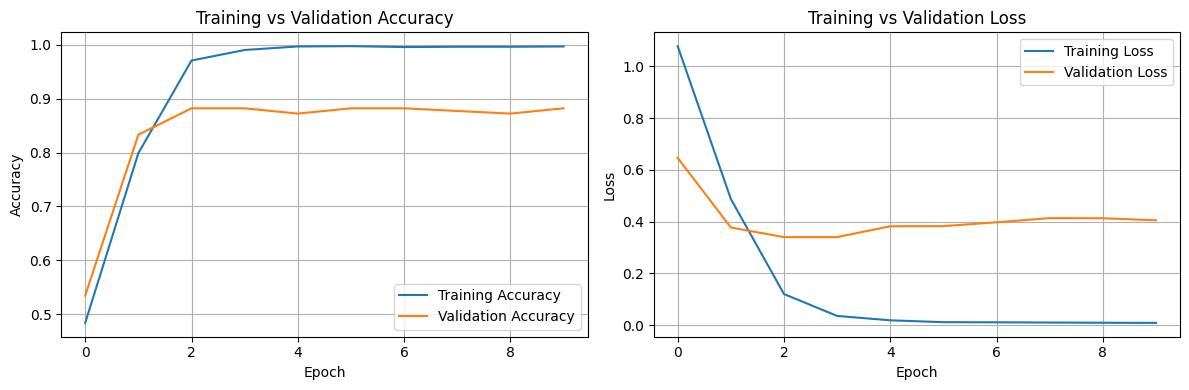

In [ ]:
############################
### Plot training curves ###
############################
# Create a single figure with 1 row and 2 columns (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- Plot 1: Training Accuracy ----
# Accuracy curve helps us track how well the model correctly classifies queries
# across epochs (iterations over the dataset).
# This plot show over- or under-fitting:
  # If both training & validation accuracy increase steadily: good learning.
  # If training accuracy goes up but validation accuracy goes down >> overfitting.
  # If both low >> underfitting or need more epochs.
axes[0].plot(history.history["accuracy"], label="Training Accuracy") # Plot training accuracy per epoch
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy") # Plot validation accuracy per epoch
axes[0].set_xlabel("Epoch") # Label x-axis as "Epoch", number of training epochs
axes[0].set_ylabel("Accuracy") # Label y-axis as "Accuracy", accuracy value (0.0 to 1.0)
axes[0].set_title("Training vs Validation Accuracy") # Set plot title
axes[0].legend() # Show legend for the curves
axes[0].grid(True)

# ---- Plot 2: Training Loss ----
# Loss measures the model’s internal error before accuracy is computed.
# It’s often smoother and more sensitive to overfitting than accuracy.
# The loss plot shows whether the optimisation is still improving.
  # If Both training and validation loss decreasing together >> model is learning properly; optimisation is improving.
  # If Training loss dropping but validation loss rising >> model is overfitting
    #(memorising training examples instead of learning general rules) so we might need: more data,
    # more regularisation (Dropout), or stop training earlier (use “early stopping”).
  # If both losses flat lines >> Model stuck or learning finished
axes[1].plot(history.history["loss"], label="Training Loss") # Plot training loss per epoch
axes[1].plot(history.history["val_loss"], label="Validation Loss") # Plot validation loss per epoch
axes[1].set_xlabel("Epoch") # Label x-axis as "Epoch", number of training epochs
axes[1].set_ylabel("Loss")  # Label y-axis as "Loss"
axes[1].set_title("Training vs Validation Loss") # Set plot title
axes[1].legend() # Show legend for the curves
axes[1].grid(True)

# Tight layout prevents overlapping labels between the two plots.
plt.tight_layout()
plt.show() # Display the plots

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.824

Classification report:
               precision    recall  f1-score   support

           0      0.812     0.828     0.820       424
           1      0.835     0.820     0.828       451

    accuracy                          0.824       875
   macro avg      0.824     0.824     0.824       875
weighted avg      0.824     0.824     0.824       875



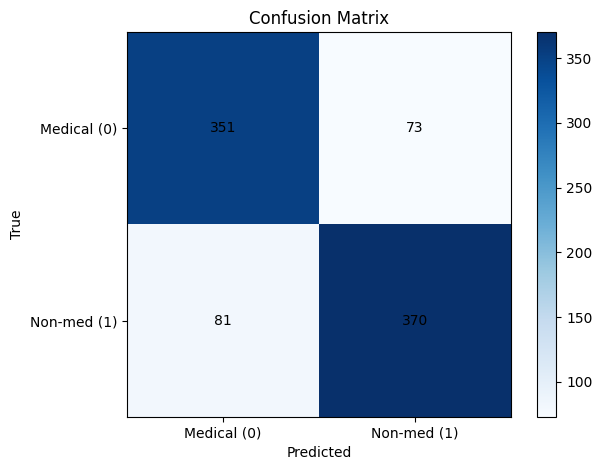

In [ ]:
##############################
### Evaluation on test set ###
##############################
# Get model predictions (probabilities):
# The model outputs probabilities between 0 and 1 for each test example.
# Each value represents the model’s confidence that the query belongs to class 1 (non-medical).
# Example: a prediction of 0.85 means the model thinks there’s an 85% chance the query is non-medical.
# The shape returned by Keras is (num_samples, 1), i.e. a 2D array, so we use .ravel()
# to flatten it into a 1D array for easier manipulation.
y_prob = model.predict(X_test).ravel()
# Convert probabilities to binary class predictions:
# We use a threshold of 0.5 to classify:
# - If probability ≥ 0.5: predict class 1 (non-medical)
# - If probability <  0.5: predict class 0 (medical)
# This threshold can be adjusted later (for example, lowering it to 0.4 might increase recall for medical queries).
# .astype(int) converts boolean True/False results into numeric 1/0 for metric calculations.
y_pred = (y_prob >= 0.5).astype(int)

# Compute overall Accuracy:
# Accuracy = (Number of correct predictions) / (Total number of predictions)
# It measures how often the model predicts correctly overall.
print("Accuracy:", accuracy_score(y_test, y_pred))
# classification_report shows multiple key metrics per class:
#   - Precision: of all examples predicted as that class, how many were actually correct?
#       >> High precision means few false positives.
#   - Recall: of all examples that truly belong to that class, how many did the model correctly detect?
#       >> High recall means few false negatives.
#   - F1-score: harmonic mean of precision and recall(balances both).
#   - Support: number of true samples belonging to that class (not a metric, just a count).
# digits=3 → round results to 3 decimal places.
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

# creates a confusion matrix showing counts of true vs predicted labels
# Create and visualise a Confusion Matrix
# confusion_matrix shows how many examples were correctly and incorrectly classified.
# Rows represent true labels, columns represent predicted labels:
#       Predicted 0     Predicted 1
# True 0   True Pos      False Neg
# True 1   False Pos     True Neg
Conf_mat = confusion_matrix(y_test, y_pred)

# Display the confusion matrix visually using matplotlib
# plt.imshow displays the numeric matrix as a coloured image.
# cmap="Blues" uses blue shades to represent values (darker = higher count).
plt.imshow(Conf_mat, cmap="Blues")
plt.title("Confusion Matrix")               # Set plot title
plt.colorbar()                              # Add a color bar to interpret shades of blue (counts intensity)
# Set x-axis and y-axis tick labels for readability.
plt.xticks([0,1], ["Medical (0)", "Non-med (1)"])
plt.yticks([0,1], ["Medical (0)", "Non-med (1)"])

for i in range(2):                          # Loop over rows (true labels)
    for j in range(2):                      # Loop over columns (predicted labels)
        plt.text(j, i, Conf_mat[i, j], ha="center", va="center")  # Write the count in each cell, centered

plt.xlabel("Predicted")                     # Label x-axis
plt.ylabel("True")                          # Label y-axis
plt.tight_layout()                          # Adjust layout to fit everything
plt.show()                                  # Display the plot


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


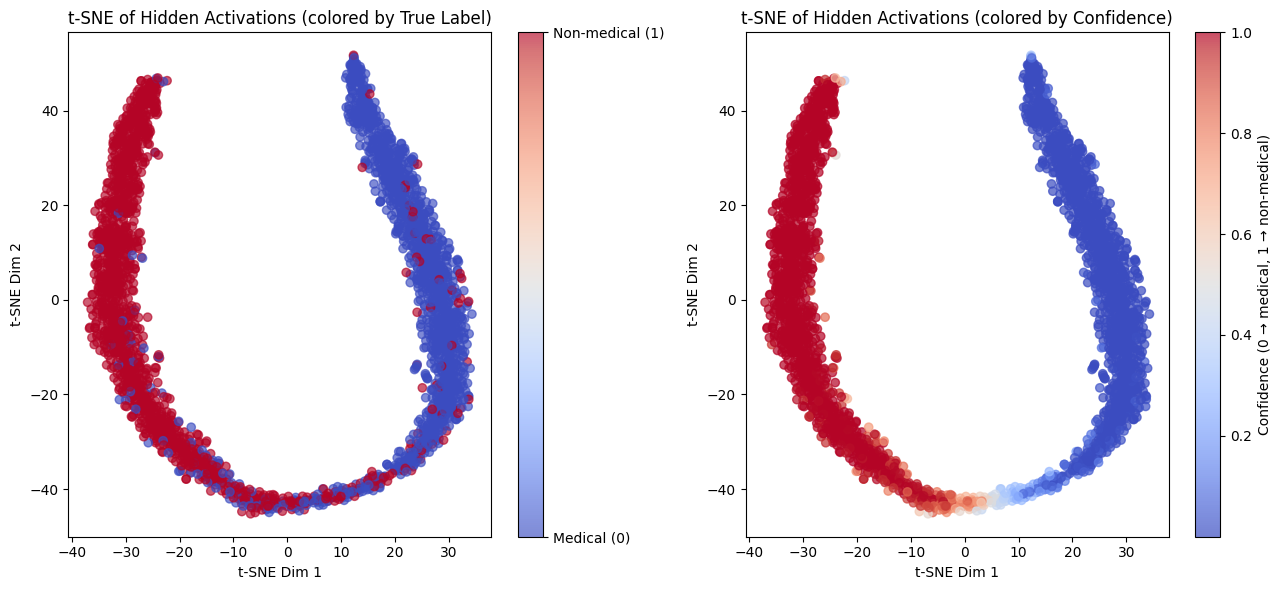

In [ ]:
####################################################################
### Feature Entanglement (visualise learned features with t-SNE) ###
####################################################################
# reload the trained model
model = keras.models.load_model("trained_model.keras")

# Build a feature extractor model
# We want to look at the internal representation that the network learned,
# not just the final output.
# 'model.layers' is a list of all layers in the original model:
#   [Input, Dense(256), Dropout, Dense(64), Dense(1)]
# 'model.layers[:-1]' drops the last layer (Dense(1) with sigmoid),
# so we keep everything up to the second-to-last layer (the 64-unit Dense).
get_hidden_output = keras.Sequential(model.layers[:-1])

# Prepare data to visualize
# We don't need the entire dataset because t-SNE is slow on huge inputs,
# so we take up to 5000 samples from train and 5000 from test and stack them.
# np.vstack stacks rows from both sets into one big array.
# X_all: feature vectors for those samples
# y_all: the true labels (0 = medical, 1 = non-medical) for coloring the plot
X_all = np.vstack([X_train[:5000], X_test[:5000]])
y_all = np.concatenate([y_train[:5000], y_test[:5000]])

# Get hidden layer activations
# We pass X_all through the network without the final output layer.
# This gives us the internal 64-dimensional representation for each query.
# If two queries have similar hidden representations,
# the model thinks of them as similar.
H = get_hidden_output.predict(X_all, batch_size=256)


# Standardize features
# StandardScaler() rescale each dimension of H to have mean 0 and std 1.
# That can help some distance-based methods like t-SNE or UMAP.
# H_std = StandardScaler().fit_transform(H)


# Use PCA before t-SNE
# Why PCA first?
#   - H (the hidden layer) is 64-dimensional.
#   - t-SNE works better (and faster) if we reduce dimensionality first.
#   - PCA keeps the directions of maximum variance and denoises the data.
# We reduce H down to 50 principal components with PCA.
# Even though 50 > 2, this helps t-SNE structure the data.
H_pca = PCA(n_components=50, random_state=SEED).fit_transform(H)

# Apply t-SNE to get 2D embeddings
# t-SNE (t-distributed Stochastic Neighbor Embedding)
# tries to place similar points close together in 2D,
# and dissimilar points far apart.
# parameters:
# - n_components=2: project down to 2D so we can plot it
# - perplexity: how many neighbors do I consider local structure from?
#   typical good range: 20–50
# - max_iter: how long t-SNE optimizes the layout
# - learning_rate: step size for t-SNE's gradient descent
# - metric='cosine': distance measure; cosine is often better for high-dim text data
# - random_state=SEED: reproducibility
tsne = TSNE(
    n_components=2,
    perplexity=40,            # controls local vs global structure (higher = more global smoothing)
    max_iter=1500,            # adjust between 1500–2000 for smoother layouts (#more iterations = more stable embedding)
    learning_rate=200,        # or 500, 800
    metric='cosine',          # often better for text features, tunes t-SNE
    random_state=SEED
)
# H2 will be an array of shape (num_points, 2)
# Each row is the 2D t-SNE projection of a query's hidden representation.
H2 = tsne.fit_transform(H_pca)

# Compute model's confidence for each query
# We now ask the FULL model (with the final sigmoid layer) to predict the
# probability for each input in X_all.
# 'probs' is in [0, 1]:
#   - values close to 0: model thinks "medical (0)"
#   - values close to 1: model thinks "non-medical (1)"
# We'll use this later to color the second plot by confidence, not just true label.
probs = model.predict(X_all, batch_size=256).ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 6)) # build side-by-side plots

# Plot (A): t-SNE coloured by the TRUE CLASS label
# Here we colour points based on y_all (0 = medical, 1 = non-medical).
# If the network has learned to separate classes, we should see some grouping,
# one area for medical queries and one for non-medical queries.
sc1 = axes[0].scatter(
    H2[:,0], H2[:,1],
    c=y_all,            # colour = actual class
    cmap="coolwarm",    # blue<>red ish map
    alpha=0.65)         # slightly transparent points
axes[0].set_title("t-SNE of Hidden Activations (colored by True Label)")
axes[0].set_xlabel("t-SNE Dim 1")
axes[0].set_ylabel("t-SNE Dim 2")
# Add a colourbar legend that maps 0/1 to text labels
cbar1 = plt.colorbar(sc1, ax=axes[0], ticks=[0,1])
cbar1.ax.set_yticklabels(["Medical (0)", "Non-medical (1)"])

# Plot (B): t-SNE coloured by MODEL'S CONFIDENCE
# Now instead of colouring by true label, we colour by the model's probability output.
# This shows areas where the model feels "very sure" vs "unsure".
# • Redder points (high probs close to 1.0) = "I'm confident this is non-medical"
# • Bluer points (low probs close to 0.0)   = "I'm confident this is medical"
# • Middle colours = uncertain region
# c=probs: predicted probability of class 1
sc2 = axes[1].scatter(H2[:,0], H2[:,1], c=probs, cmap="coolwarm", alpha=0.7)
axes[1].set_title("t-SNE of Hidden Activations (colored by Confidence)")
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")
# Add a colorbar that indicates what the colours mean:
# near 0: model thinks "medical (0)"
# near 1: model thinks "non-medical (1)"
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label("Confidence (0 → medical, 1 → non-medical)")

plt.tight_layout()  # adjusts subplot spacing to prevent overlap
plt.show()


In [ ]:
#####################################
### PGD Attack (robustness check) ###
#####################################
# define a PGD (Projected Gradient Descent) adversarial attack to:
#   - Slightly modify the input features in a smart way
#   - Make the model change its prediction
#   - BUT keep the changes "small" so they are still realistic
# This tests how fragile the model is to worst-case perturbations around each sample.

def pgd_linf(model, x_np, y_np, eps=0.10, alpha=0.02, iters=10):
    """
    L∞ PGD attack on feature space.
    Inputs:
    - model : the trained Keras model we’re attacking
    - x_np  : clean input batch (shape: [batch_size, num_features])
    - y_np  : true labels for that batch (0 or 1)
    - eps   : maximum total perturbation (epsilon ball radius, L∞ norm)
              >> how far we’re allowed to push each feature from its original value
    - alpha : size of each attack step
              >> how aggressively we move in the direction that increases loss
    - iters : how many attack steps to take

    Output:
    - x_adv : adversarial version of x_np, same shape as x_np
              >> these are "attacked" inputs designed to fool the model
    """
    # Make a copy so we don't modify the original inputs.
    # Ensure type float32 for TensorFlow compatibility.
    x_adv = x_np.copy().astype("float32")

    # Convert true labels (0 or 1) to a TensorFlow tensor of floats.
    # y_tf will be used to compute the loss with respect to the correct label.
    y_tf = tf.convert_to_tensor(y_np.astype("float32"))

    # Iterative attack loop: take multiple small gradient (slope vectors) steps,
    # each step trying to make the model's prediction worse (higher loss).
    for _ in range(iters):
      # Convert current adversarial candidate (x_adv) to a TensorFlow variable
        x_tf = tf.convert_to_tensor(x_adv)
        x_tf = tf.Variable(x_tf)
        # GradientTape: compute gradients (slop vector) of the loss w.r.t. the input features.
        with tf.GradientTape() as tape:
          # Forward pass: get model predictions for current adversarial inputs.
            logits = model(x_tf, training=False)
            # Reshape model outputs from (batch_size, 1) to (batch_size,)
            # so it matches the shape of y_tf (which is also (batch_size,))
            logits = tf.reshape(logits, [-1])
            # Compute cross-entropy loss:
            #   Higher loss means the model is doing worse at matching y_tf.
            # The attacker wants to PUSH this loss UP.
            loss = keras.losses.binary_crossentropy(y_tf, logits)
        # Compute gradient of the loss with respect to the inputs.
        # grad has the same shape as x_tf: [batch_size, num_features]
        grad = tape.gradient(loss, x_tf).numpy()
        # Take a step in the direction that increases the loss.
        # use the sign of the gradient (this gives an L∞-style step).
        # alpha controls how big that step is.
        # This is the core of "gradient-based attack": move input in the
        # direction that most hurts the model.
        x_adv = x_adv + alpha * np.sign(grad) # Gradient sign step
        # Project the updated adversarial example back into the allowed epsilon-ball
        # around the ORIGINAL input x_np.
        # L∞ constraint:
        #   |x_adv - x_np| <= eps, for every feature.
        # np.clip(x_adv, x_np - eps, x_np + eps) enforces:
        #    Each feature of x_adv can only move at most `eps`
        #    away from the original x_np value.
        x_adv = np.clip(x_adv, x_np - eps, x_np + eps)
        # ensure input stays in valid range [0,1]
        # Without this, PGD might push values slightly <0 or >1.
        x_adv = np.clip(x_adv, 0.0, 1.0)
    # After running all PGD steps, return the adversarially perturbed batch.
    return x_adv


# Run the PGD attack on the entire test set
# eps   = how strong the total allowed perturbation is (the "radius" of allowed noise)
# alpha = size of each gradient step
# iters = how many steps of attack to take
eps, alpha, iters = 0.10, 0.02, 10
# generate adversarial examples for the whole test set.
# then store them in X_test_adv, which has the same shape as X_test.
B = 256 # batch size for attack generation (do PGD in chunks to save memory)
X_test_adv = np.zeros_like(X_test)

# Loop over test data in batches of size B.
# For each batch:
#   - xb is the clean inputs
#   - yb is the true labels
#   - we generate adversarial xb' using pgd_linf
#   - we store the result in the matching slice of X_test_adv
for i in range(0, len(X_test), B):
    xb = X_test[i:i+B]
    yb = y_test[i:i+B]
    X_test_adv[i:i+len(xb)] = pgd_linf(model, xb, yb, eps=eps, alpha=alpha, iters=iters)

# Evaluate the model on clean vs attacked data
# Clean predictions:
# run the model on the original, untouched test set.
# .ravel() converts Keras output shape (N,1) to (N,)
y_pred_clean = (model.predict(X_test).ravel() >= 0.5).astype(int)
# Adversarial predictions:
# run the same model on the adversarially perturbed inputs X_test_adv.
# If the model is NOT robust, its predictions will flip a lot here.
y_pred_adv   = (model.predict(X_test_adv).ravel() >= 0.5).astype(int)

# Compute accuracy in the clean case and the attacked case.
# clean_acc  = normal test accuracy (baseline performance)
# robust_acc = accuracy under strongest attack we tried (robust accuracy).
# A large drop means: the model is easily fooled by tiny, targeted perturbations.
# A small drop means: the model is robust / dependable under adversarial pressure.
clean_acc  = accuracy_score(y_test, y_pred_clean)
robust_acc = accuracy_score(y_test, y_pred_adv)

print(f"Clean accuracy:  {clean_acc:.4f}")
print(f"Robust accuracy: {robust_acc:.4f}  (PGD eps={eps}, alpha={alpha}, iters={iters})")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Clean accuracy:  0.8240
Robust accuracy: 0.0057  (PGD eps=0.1, alpha=0.02, iters=10)


In [ ]:
####################################################
### Adversarial Training (to improve robustness) ###
####################################################
# Select a subset of the training data
# Adversarial training is computationally expensive because for each sample we
# must generate an adversarial version by running PGD (which itself has loops).
# Therefore, we take a smaller subset of the training data to keep runtime reasonable.
# Here we take either 2000 samples.
subset = min(2000, len(X_train))
X_train_sub = X_train[:subset] # first N samples of training inputs
y_train_sub = y_train[:subset] # corresponding labels


# Create adversarial versions of that subset
# We use the same PGD attack defined earlier to produce adversarial examples
# (perturbed inputs that make the model’s predictions worse).
# These will be used for "adversarial training", teaching the model to recognize
# and correctly classify attacked samples as well.
# Initialize an empty array to store adversarial examples for the subset.
X_train_adv = np.zeros_like(X_train_sub)
# loop through the subset in mini-batches of size B (256).
# For each batch:
#   - extract xb (clean features) and yb (their labels)
#   - Use PGD attack function (pgd_linf) to generate adversarial versions
#   - Store them in X_train_adv
for i in range(0, len(X_train_sub), B):
    xb = X_train_sub[i:i+B] # batch of features
    yb = y_train_sub[i:i+B] # batch of true labels
    # Generate adversarial batch with the same PGD settings (eps, alpha, iters)
    X_train_adv[i:i+len(xb)] = pgd_linf(model, xb, yb, eps=eps, alpha=alpha, iters=iters)

# Combine clean + adversarial samples
# Adversarial training means teaching the model to perform well
# not only on clean data but also on attacked (perturbed) data.
# So we merge all original clean training data (X_train, y_train)
# plus the adversarial subset (X_train_adv, y_train_sub)
X_comb = np.vstack([X_train, X_train_adv]) # stack rows of both datasets
y_comb = np.concatenate([y_train, y_train_sub]) # combine corresponding labels

# Shuffle combined data
# shuffle to mix clean and adversarial examples randomly
# so the model doesn't see all clean examples first and all adversarial ones later.
# rng.permutation returns a shuffled list of indices.
rng = np.random.RandomState(SEED)
perm = rng.permutation(len(X_comb))
X_comb = X_comb[perm]; y_comb = y_comb[perm]

# train a new model on this combined data
# Build a new model with the same architecture as before
# do not continue training the old one to ensure a fair comparison
model_adv = build_model(X_comb.shape[1])

# Train it using the same parameters as the original
# This time, however, the training set includes both clean and adversarial samples,
# which encourages the model to learn smoother, more robust decision boundaries.
history_adv = model_adv.fit(
    X_comb, y_comb,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1,
    class_weight=class_weight_dict_manu
)


# Evaluate the adversarially-trained model
# A) Evaluate on clean test data
# Run the adversarially-trained model on the original, untouched test set.
y_pred_clean2 = (model_adv.predict(X_test).ravel() >= 0.5).astype(int)

# B) Generate new adversarial test samples
# generate a fresh set of adversarial test data using the new model
# (not the old one) to see if the retrained model is harder to fool.
X_test_adv2 = np.zeros_like(X_test)
for i in range(0, len(X_test), B):
    xb = X_test[i:i+B]
    yb = y_test[i:i+B]
    X_test_adv2[i:i+len(xb)] = pgd_linf(model_adv, xb, yb, eps=eps, alpha=alpha, iters=iters)

# C) Evaluate on adversarial test data
y_pred_adv2 = (model_adv.predict(X_test_adv2).ravel() >= 0.5).astype(int)

# Compute both accuracies to compare with baseline (before adversarial training)
# clean_acc, robust_acc: baseline model’s performance (from earlier PGD test)
# clean_acc2, robust_acc2: after adversarial training
# Usually, clean accuracy might drop slightly
# but robust accuracy should improve (model less fooled by perturbations).
clean_acc2  = accuracy_score(y_test, y_pred_clean2)
robust_acc2 = accuracy_score(y_test, y_pred_adv2)
print(f"\n[Baseline] clean={clean_acc:.4f}  robust={robust_acc:.4f}")
print(f"[AdvTrain] clean={clean_acc2:.4f}  robust={robust_acc2:.4f}")

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7038 - loss: 0.7718 - val_accuracy: 0.8119 - val_loss: 0.2977
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8771 - loss: 0.3063 - val_accuracy: 0.8985 - val_loss: 0.2463
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9867 - loss: 0.0799 - val_accuracy: 0.8812 - val_loss: 0.3211
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9961 - loss: 0.0200 - val_accuracy: 0.8564 - val_loss: 0.4055
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9985 - loss: 0.0101 - val_accuracy: 0.8639 - val_loss: 0.4498
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9981 - loss: 0.0074 - val_accuracy: 0.8589 - val_loss: 0.5466
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9985 - loss: 0.0062 - val_accuracy: 0.8589 - val_loss: 0.5234
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9993 - loss: 0.0048 - val_accu

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


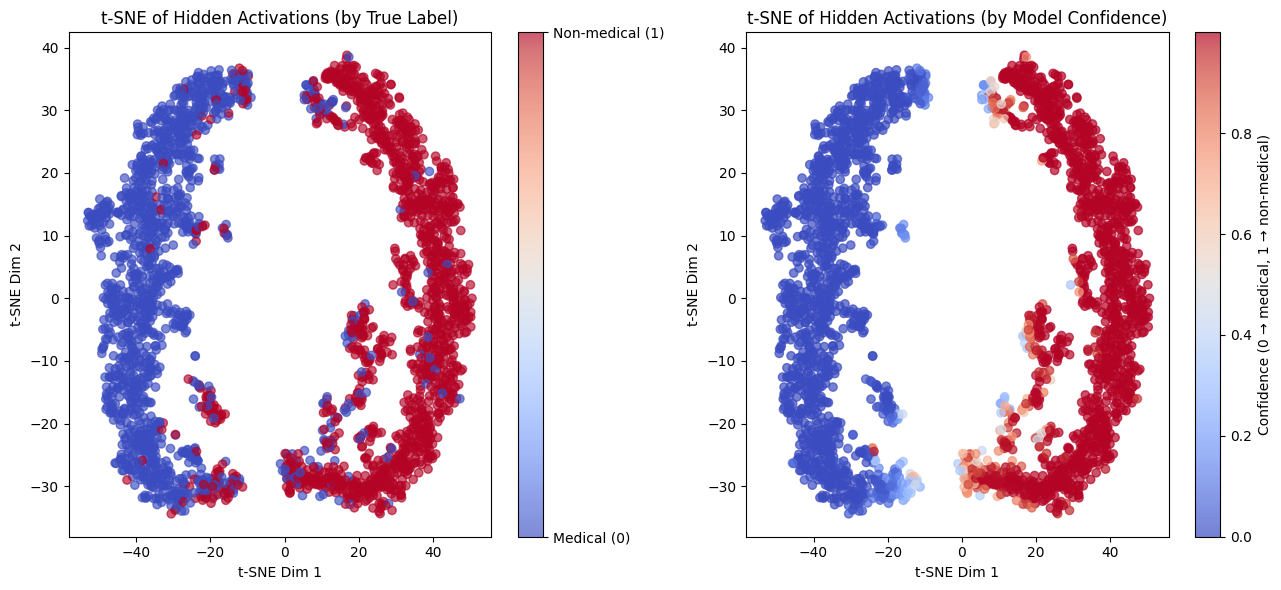

In [ ]:
#############################################################################
### Feature entanglement (t-SNE visualisation after adversarial training) ###
#############################################################################
# Use all layers except the final output layer to get hidden features
get_hidden_output = keras.Sequential(model_adv.layers[:-1])

# Collect a subset for speed and clarity
X_all = np.vstack([X_train[:5000], X_test[:5000]])
y_all = np.concatenate([y_train[:5000], y_test[:5000]])

# Extract hidden activations
H = get_hidden_output.predict(X_all, batch_size=256)

# --- Dimensionality reduction before t-SNE ---
# PCA to 50 components (denoise + speed up t-SNE)
H_pca = PCA(n_components=50, random_state=SEED).fit_transform(H)

# --- t-SNE embedding to 2D space ---
tsne = TSNE(
    n_components=2,
    perplexity=40,          # try 30–50 for tuning
    max_iter=1500,
    learning_rate=200,
    metric="cosine",
    random_state=SEED
)
H2 = tsne.fit_transform(H_pca)

# --- Plot the t-SNE embeddings ---
# 1) Colour by true labels
# 2) Colour by model confidence

# Model confidence (probability of class 1 = non-medical)
probs = model_adv.predict(X_all, batch_size=256).ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# (A) Plot by true label
sc1 = axes[0].scatter(H2[:,0], H2[:,1], c=y_all, cmap="coolwarm", alpha=0.65)
axes[0].set_title("t-SNE of Hidden Activations (by True Label)")
axes[0].set_xlabel("t-SNE Dim 1")
axes[0].set_ylabel("t-SNE Dim 2")
cbar1 = plt.colorbar(sc1, ax=axes[0], ticks=[0,1])
cbar1.ax.set_yticklabels(["Medical (0)", "Non-medical (1)"])

# (B) Plot by model confidence
sc2 = axes[1].scatter(H2[:,0], H2[:,1], c=probs, cmap="coolwarm", alpha=0.7)
axes[1].set_title("t-SNE of Hidden Activations (by Model Confidence)")
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label("Confidence (0 → medical, 1 → non-medical)")

plt.tight_layout()
plt.show()